# 06 · Demand response — price elasticity of occupancy

Part 7 of the brief. Estimates how room occupancy responds to the **real**
room rate, per category, with monthly seasonal controls and a time trend.

Specifications compared:
1. **log–log**  `ln(occ) = α + β ln(realRate) + γ infl + Σ month + δ t + ε`
2. **log–log + lag**  adds `ln(realRate)_{t-1}`
3. **levels**  `occ_pp = a + b realRate + …`  (occupancy in percentage points)
4. **logit (bounded)**  `logit(occ/100) = α + β ln(realRate) + …`
   (occupancy is a bounded rate; the logit link keeps fitted values in (0,1))

`β` from spec 1 is the **elasticity of the occupancy rate** w.r.t. the real
rate — *not* a room-demand elasticity, and **not causal** (see the endogeneity
section). HAC (Newey–West, 6 lag) standard errors throughout.

**Input** `03_analysis_panel.parquet` →
**Output** `outputs/tables/table3_elasticity.csv`, `elasticity_robustness.csv`,
`outputs/figures/06_*.png`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("06_elasticity")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS)
df = df[df.in_window == 1].copy()
MONTHS = [f"m{m:02d}" for m in range(2, 13)]
LAB = C.CATEGORY_LABELS
CATS = C.MODEL_CATEGORIES
HAC = dict(cov_type="HAC", cov_kwds={"maxlags": 6})


def prep(cat, occ="room_occupancy", defl="real_rate_gba", sample="covid_excl"):
    s = df[df.hotel_category == cat].sort_values("date").copy()
    s = s[s[occ].notna() & s[defl].notna() & (s[occ] > 0)]
    if sample == "covid_excl":
        s = s[s.covid_any == 0]
    elif sample == "incl_2022":
        s = s[s.covid_hole == 0]
    elif sample == "ex_extreme":
        s = s[(s.covid_any == 0) &
              (s.infl_mom_gba.abs() <= s.infl_mom_gba.abs().quantile(.90))]
    s["ln_occ"] = np.log(s[occ])
    s["occ_pp"] = s[occ]
    s["ln_rr"] = np.log(s[defl])
    s["ln_rr_l1"] = s["ln_rr"].shift(1)
    s["logit_occ"] = np.log((s[occ] / 100) / (1 - s[occ] / 100))
    s["infl"] = s["infl_mom_gba"]
    s["trend"] = s["t"]
    return s


def run(y, s, regs):
    d = s.dropna(subset=[y] + regs)
    X = sm.add_constant(d[regs + MONTHS].astype(float))
    m = sm.OLS(d[y].astype(float), X).fit(**HAC)
    return m

## 1 · Main table — elasticity β by category and specification

(sample = in-window, COVID 2020-03…2022-12 excluded, GBA real rate)

In [2]:
rows = []
for cat in CATS:
    s = prep(cat)
    specs = {
        "loglog": ("ln_occ", ["ln_rr", "infl", "trend"], "ln_rr"),
        "loglog_lag": ("ln_occ", ["ln_rr", "ln_rr_l1", "infl", "trend"], "ln_rr"),
        "loglog_lag_sum": ("ln_occ", ["ln_rr", "ln_rr_l1", "infl", "trend"], "SUM"),
        "levels": ("occ_pp", ["real_rate_gba", "infl", "trend"], "real_rate_gba"),
        "logit": ("logit_occ", ["ln_rr", "infl", "trend"], "ln_rr"),
    }
    for name, (y, regs, key) in specs.items():
        m = run(y, s, regs)
        if key == "SUM":
            b = m.params["ln_rr"] + m.params["ln_rr_l1"]
            # delta-method SE for the sum
            cov = m.cov_params().loc[["ln_rr", "ln_rr_l1"], ["ln_rr", "ln_rr_l1"]]
            se = float(np.sqrt(np.array([1, 1]) @ cov.values @ np.array([1, 1])))
            t = b / se
        else:
            b, se, t = m.params[key], m.bse[key], m.tvalues[key]
        rows.append(dict(hotel_category=cat, label=LAB[cat], spec=name,
                         beta=round(float(b), 3), se=round(float(se), 3),
                         t=round(float(t), 2), n=int(m.nobs),
                         r2=round(m.rsquared, 3)))
tab3 = pd.DataFrame(rows)
tab3.to_csv(C.OUT_TAB / "table3_elasticity.csv", index=False)
LOG.log("write", "table3_elasticity.csv", len(tab3))
tab3.pivot_table(index=["hotel_category", "label"], columns="spec",
                 values=["beta", "t"]).round(3)

  [06_elasticity] write                  table3_elasticity.csv                  30  


beta                                          \
spec                       levels  logit loglog loglog_lag loglog_lag_sum   
hotel_category label                                                        
apart          Apart-hotel  0.004  0.077  0.056     -0.012          0.103   
boutique       Boutique     0.004  0.296  0.112      0.300          0.085   
stars_1_2      1-2 star     0.079  1.874  0.997      0.946          1.036   
stars_3        3 star       0.026  0.879  0.323      0.294          0.331   
stars_4        4 star       0.001 -0.031  0.010      0.066         -0.003   
stars_5        5 star      -0.001 -0.089 -0.033     -0.027         -0.064   

                                t                                         
spec                       levels logit loglog loglog_lag loglog_lag_sum  
hotel_category label                                                      
apart          Apart-hotel   0.70  0.27   0.52      -0.19           0.75  
boutique       Boutique      1.37  1.31   1.44       2.43           1.14  
stars_1_2      1-2 star      7.03  6.54   5.72       2.89          11.45  
stars_3        3 star        2.84  2.44   2.37       1.92           2.40  
stars_4        4 star        0.14 -0.11   0.11       0.39          -0.04  
stars_5        5 star       -0.60 -0.44  -0.49      -0.51          -0.95

## 2 · Robustness grid — log–log β under alternative choices

In [3]:
rob = []
for cat in CATS:
    for occ in ["room_occupancy", "bed_occupancy"]:
        for defl in ["real_rate_gba", "real_rate_nac"]:
            for samp in ["covid_excl", "incl_2022", "ex_extreme"]:
                s = prep(cat, occ=occ, defl=defl, sample=samp)
                if len(s) < 30:
                    continue
                m = run("ln_occ", s, ["ln_rr", "infl", "trend"])
                rob.append(dict(hotel_category=cat, label=LAB[cat], occ=occ,
                                deflator=defl, sample=samp,
                                beta=round(m.params["ln_rr"], 3),
                                t=round(m.tvalues["ln_rr"], 2), n=int(m.nobs)))
rob = pd.DataFrame(rob)
rob.to_csv(C.OUT_TAB / "elasticity_robustness.csv", index=False)
LOG.log("write", "elasticity_robustness.csv", len(rob))
rob[(rob.occ == "room_occupancy") & (rob.deflator == "real_rate_gba")] \
    .pivot_table(index="label", columns="sample", values=["beta", "t"]).round(3)

  [06_elasticity] write                  elasticity_robustness.csv              72  


beta                               t                     
sample      covid_excl ex_extreme incl_2022 covid_excl ex_extreme incl_2022
label                                                                      
1-2 star         0.997      0.867     0.997       5.72       4.99      5.72
3 star           0.323      0.185     0.089       2.37       1.21      0.56
4 star           0.010     -0.055     0.136       0.11      -0.72      1.10
5 star          -0.033     -0.037     0.081      -0.49      -0.55      0.85
Apart-hotel      0.056      0.015     0.201       0.52       0.14      1.53
Boutique         0.112      0.049     0.125       1.44       0.68      1.56

## 3 · Chart C — "Price increases come with an occupancy trade-off"

log–log β (COVID-excluded, GBA) with 95% HAC confidence intervals. Negative β =
higher real rate associated with lower occupancy, holding season and trend fixed.

  [06_elasticity] figure                 06_chartC_elasticity.png                   


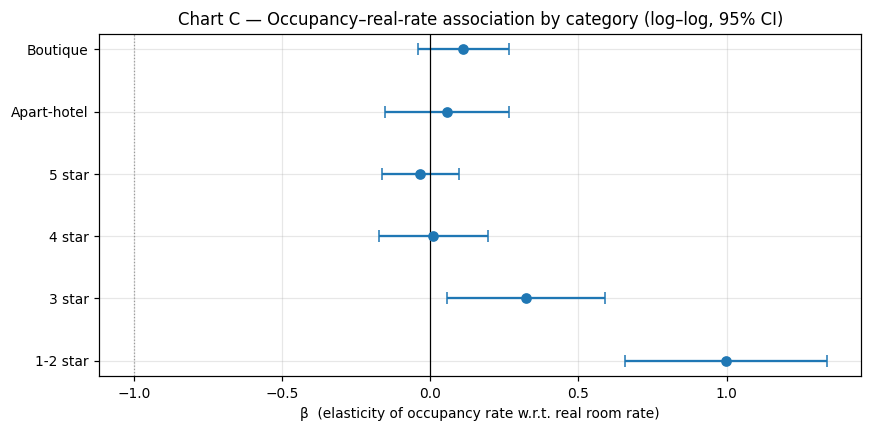

In [4]:
main = tab3[tab3.spec == "loglog"].set_index("label").loc[[LAB[c] for c in CATS]]
mse = tab3[tab3.spec == "loglog"].set_index("label").loc[[LAB[c] for c in CATS], "se"]
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(main))
ax.errorbar(main["beta"], y, xerr=1.96 * main["se"], fmt="o", capsize=4)
ax.axvline(0, color="k", lw=.8)
ax.axvline(-1, color="0.6", ls=":", lw=.8)
ax.set_yticks(y); ax.set_yticklabels(main.index)
ax.set_xlabel("β  (elasticity of occupancy rate w.r.t. real room rate)")
ax.set_title("Chart C — Occupancy–real-rate association by category (log–log, 95% CI)")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "06_chartC_elasticity.png")
LOG.log("figure", "06_chartC_elasticity.png"); plt.show()

## 4 · Partial-regression (added-variable) plots — spec 1, per category

occupancy and real rate, each residualised on month dummies + trend + inflation.
The slope of the cloud is β; this is what identifies the estimate.

  [06_elasticity] figure                 06_added_variable_plots.png                


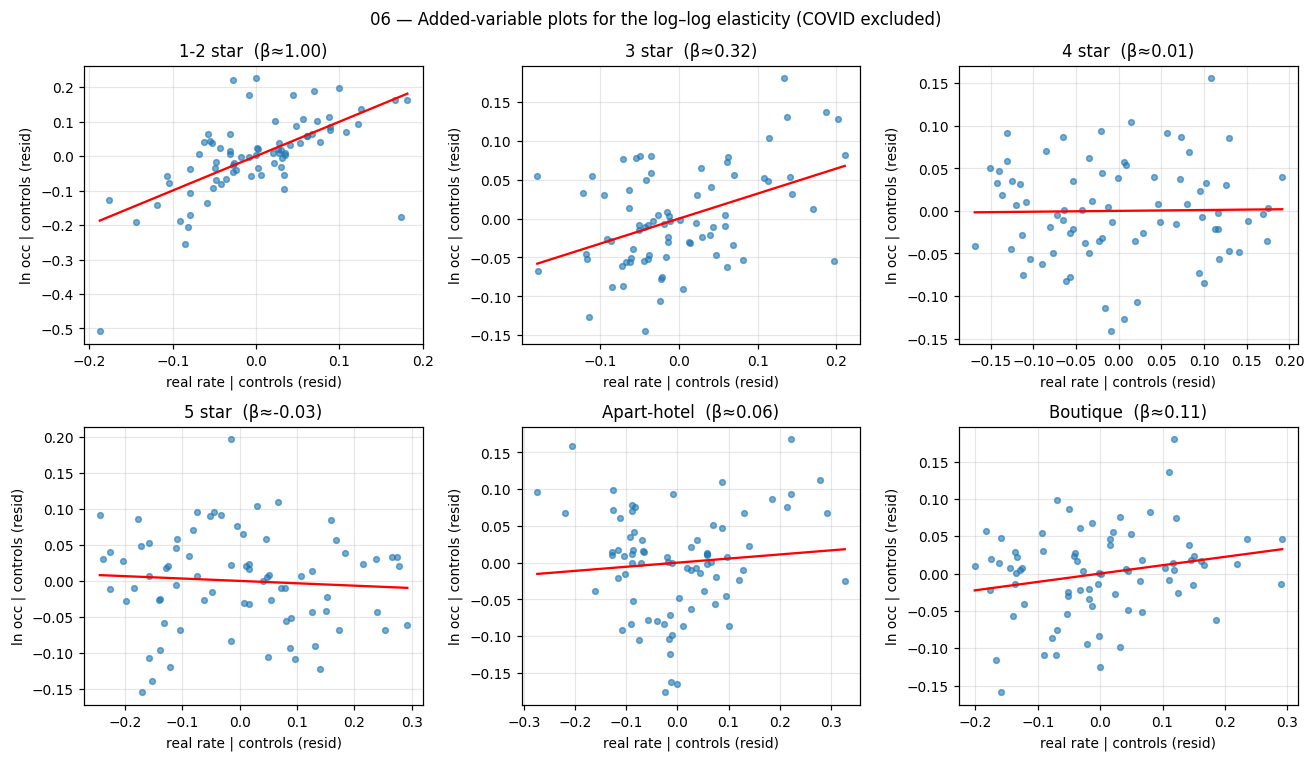

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, cat in zip(axes.ravel(), CATS):
    s = prep(cat).dropna(subset=["ln_occ", "ln_rr", "infl", "trend"])
    Z = sm.add_constant(s[["infl", "trend"] + MONTHS].astype(float))
    ry = sm.OLS(s["ln_occ"].astype(float), Z).fit().resid
    rx = sm.OLS(s["ln_rr"].astype(float), Z).fit().resid
    ax.scatter(rx, ry, s=14, alpha=.6)
    b = np.polyfit(rx, ry, 1)[0]
    xs = np.linspace(rx.min(), rx.max(), 20)
    ax.plot(xs, b * xs, "r-")
    ax.set_title(f"{LAB[cat]}  (β≈{b:0.2f})")
    ax.set_xlabel("real rate | controls (resid)"); ax.set_ylabel("ln occ | controls (resid)")
fig.suptitle("06 — Added-variable plots for the log–log elasticity (COVID excluded)")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "06_added_variable_plots.png")
LOG.log("figure", "06_added_variable_plots.png"); plt.show()

## 5 · Endogeneity — why β is an association, not a causal elasticity

The brief requires this be stated explicitly. β from the specs above should be
read as a **conditional correlation**, because:

* **Reverse causality / dynamic pricing.** Hotels raise real rates *because*
  they expect strong demand (events, holidays, favourable exchange-rate windows
  for inbound tourists). That pushes price and occupancy up together and biases
  β **upward** (toward 0 or positive) — visible in the raw scatter in nb03/nb04.
* **Omitted demand shocks.** Exchange-rate competitiveness for foreign visitors,
  Brazilian/regional demand cycles, big events (G20 2018, concerts, sport) —
  correlated with both price and occupancy, not captured by month dummies.
* **Seasonality** is only partly absorbed by calendar-month dummies; the tourist
  calendar shifts year to year (Easter, school holidays, long weekends).
* **COVID** is a structural break; excluded from the baseline, tested with
  `incl_2022`.
* **Capacity changes.** Entry/exit and refurbishment shift both the
  denominator of occupancy and the pricing environment; capacity here is only
  quarterly and lagged.
* **Inflation itself.** In this data, high-inflation months coincide with
  high-season, high-demand months (nb05 §6), so `infl` and the seasonal terms
  are entangled.

What would be needed for a causal reading: a supply-side or cost instrument for
the real rate (e.g. category-specific input-cost shocks, regulated-price
changes) — not available here. We therefore present β as descriptive and lean
on the **counterfactual demand model in nb07** with explicit elasticity
scenarios rather than a single point estimate.

In [6]:
LOG.flush()
print("06 complete.")

06 complete.
